## How are in-demand skills trendig for Data Analysts?

### Methodology

1. Aggregate skill counts monthly 
2. Re Analyze based on percentage of total jobs
3. Plot monthly skill demand

In [2]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns 

# loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# # data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [148]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title'] == 'Data Analyst')].copy()
df_DA_US['Month'] = df_DA_US['job_posted_date'].dt.month
df_DA_US_EX = df_DA_US.explode('job_skills')
df_DA_US_pivot = df_DA_US_EX.pivot_table(index='Month', columns='job_skills', aggfunc= 'size', fill_value = 0)
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()

In [149]:
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending = False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

<Axes: xlabel='Month'>

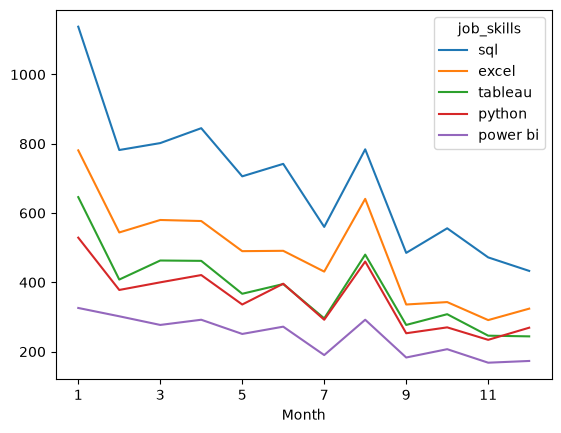

In [193]:
df_DA_US_pivot = df_DA_US_pivot.iloc[:,:5]
df_DA_US_pivot.plot(kind='line')

In [151]:
df_totals = df_DA_US.groupby('Month').size()

In [161]:
df_DA_Percent = df_DA_US_pivot.div(df_totals/100 , axis = 0)

In [162]:
df_DA_Percent.reset_index(inplace=True)
df_DA_Percent['Month'] = pd.to_datetime(df_DA_Percent['Month'],format="%m").dt.strftime('%b')

In [1]:
df_DA_Percent.set_index('Month',inplace=True)
df_DA_Percent.plot(kind='line')
df_DA_Percent

NameError: name 'df_DA_Percent' is not defined

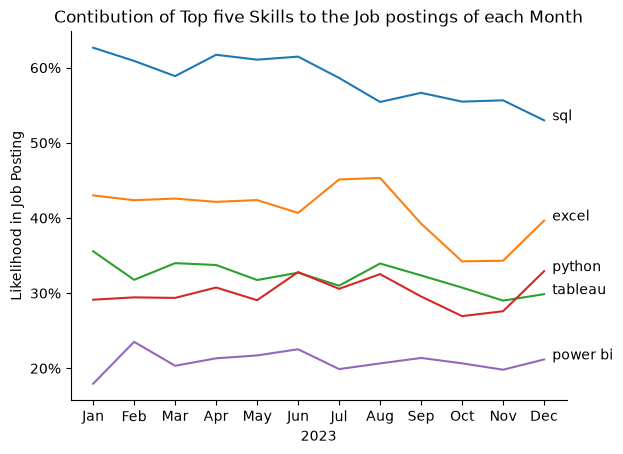

In [192]:
sns.lineplot(data=df_DA_Percent, dashes=False, legend=False)
plt.title('Contibution of Top five Skills to the Job postings of each Month')
plt.xlabel('2023')
plt.ylabel('Likelihood in Job Posting')
sns.despine()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'{int(y)}%'))
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11.2,df_DA_Percent.iloc[-1,i],df_DA_Percent.columns[i])
